# 1. Trajectory Construction

In [1]:
import math
import numpy as np
import pandas as pd
import joblib


import matplotlib.pyplot as plt
from sklearn.preprocessing import Normalizer, StandardScaler

from timeit import default_timer as timer    

def plot_two_function(title, t, y1_1, y1_2, y2_1, y2_2, color1, color2, label1, label2, label3):
    plt.figure(figsize=(15,15))
    
    plt.subplot(2, 1, 1)
    plt.grid()
    plt.plot(t, y1_1, color = color1, label = label1, linestyle = 'dashdot', linewidth = 3.5)
    plt.plot(t, y1_2, color = color2, label = label2, linewidth = 1.5)
    plt.ylabel("Inclination (degrees)")
    plt.title(title)
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.grid()
    plt.xlabel("Time (seconds)")
    plt.ylabel("Orientation (degrees)")
    plt.plot(t, y2_1, color = color1, label = label1, linestyle = 'dashdot', linewidth = 3.5)
    plt.plot(t, y2_2, color = color2, label = label3, linewidth = 1.5)
    plt.legend()
    #plt.savefig('MLP_paper_robot_trajectory_pos_recta.png')
    #plt.savefig('MLP_V3_Trajectory_degrees.png')
    return plt.show()



In [2]:
def load_trajectory_data(csv_paths, plot_configs):
    """
    Carga múltiples archivos CSV de trayectorias y prepara los datos para plot_two_function
    con configuraciones personalizadas para cada gráfica.
    
    Parámetros:
    -----------
    csv_paths : list
        Lista de rutas a los archivos CSV que contienen los datos de trayectoria
    plot_configs : list
        Lista de diccionarios con la configuración de cada gráfica:
        {
            'title': str,              # Título de la gráfica
            'color1': str,             # Color para la primera línea
            'color2': str,             # Color para la segunda línea
            'legend1': str,            # Leyenda para la primera línea
            'legend2': str,            # Leyenda para la segunda línea
            'legend3': str             # Leyenda para la tercera línea
        }
    
    Retorna:
    --------
    list
        Lista de tuplas, donde cada tupla contiene:
        (time_data, list_incli_target, incli_data, list_orient_target, orient_data, config)
    """
    import pandas as pd
    
    all_trajectories = []
    
    for path, config in zip(csv_paths, plot_configs):
        data = pd.read_csv(path)
        

        trajectory_data = (
            data['Time'].values,                # time_data
            data['Target Incli'].values,        # list_incli_target
            data['Real Incli'].values,          # incli_data
            data['Target Orient'].values,       # list_orient_target
            data['Real Orient'].values,         # orient_data
            config                             # configuración específica
        )
        
        all_trajectories.append(trajectory_data)
    
    return all_trajectories

 

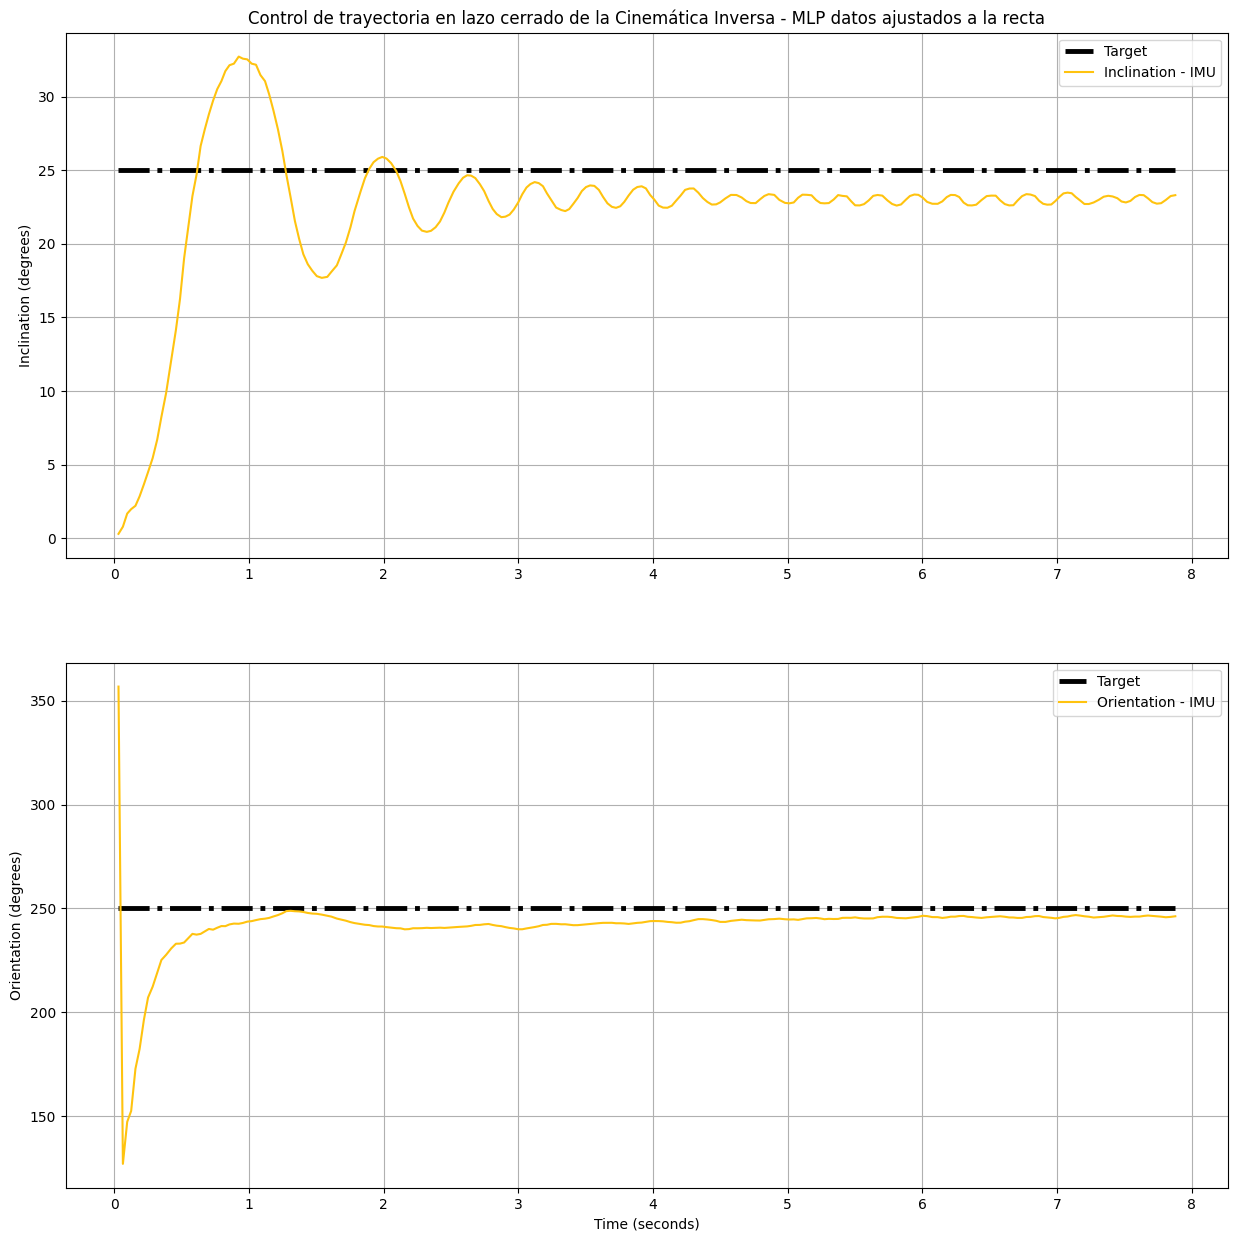

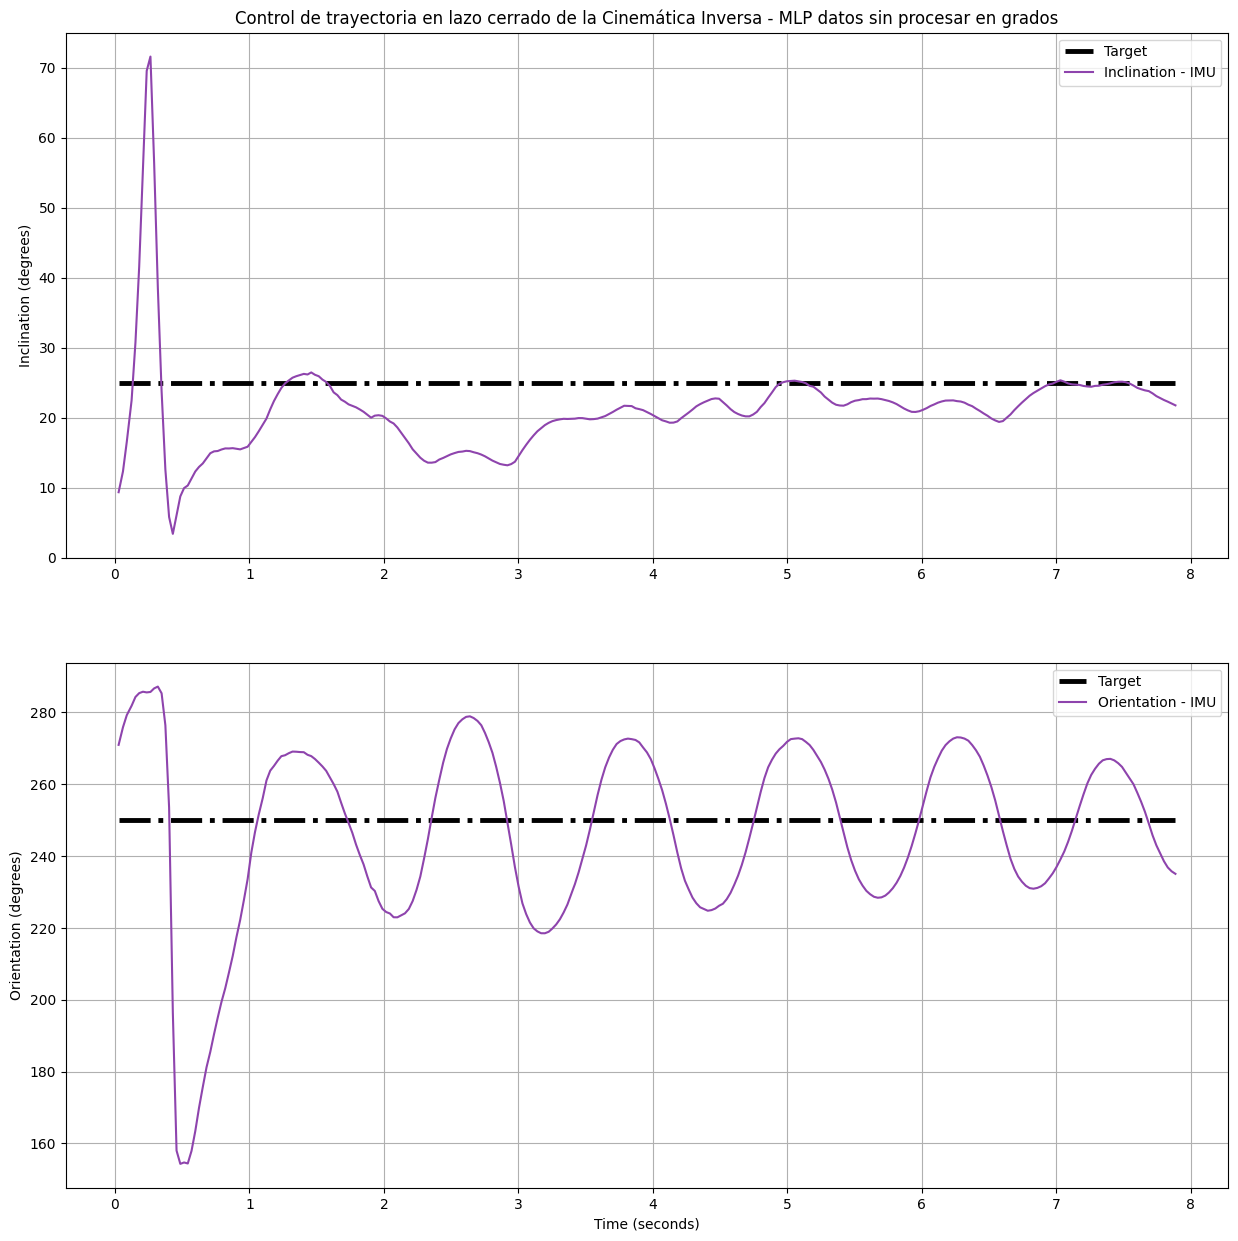

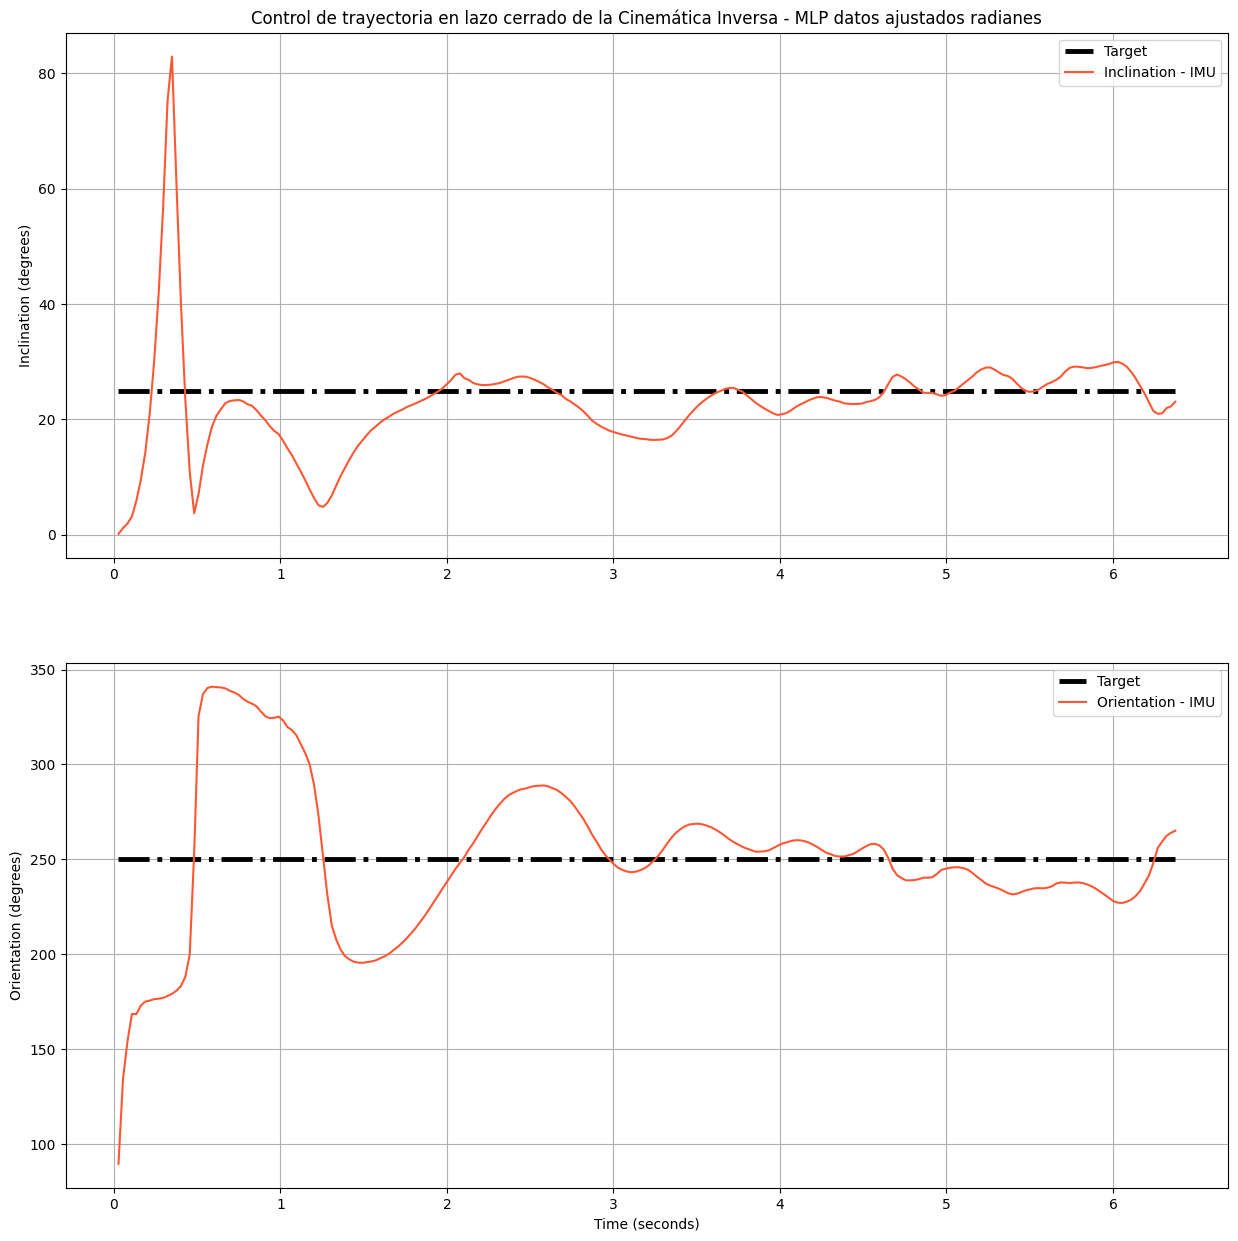

In [3]:
# Definir las rutas y configuraciones
datasets = [
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_recta.csv',
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_degree_v2.csv',
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_rad_v6.csv'

]

configs = [
    {
        'title': "Control de trayectoria en lazo cerrado de la Cinemática Inversa - MLP datos ajustados a la recta",
        'color1': "black",
        'color2': "#FFC30F",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    },
    {
        'title': "Control de trayectoria en lazo cerrado de la Cinemática Inversa - MLP datos sin procesar en grados",
        'color1': "black",
        'color2': "#8E44AD",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    },
    {
        'title': "Control de trayectoria en lazo cerrado de la Cinemática Inversa - MLP datos ajustados radianes",
        'color1': "black",
        'color2': "#FF5733",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    }
]

# Cargar-plotear los datos
trajectories = load_trajectory_data(datasets, configs)

for time_data, list_incli_target, incli_data, list_orient_target, orient_data, config in trajectories:
    plot_two_function(
        config['title'],
        time_data,
        list_incli_target,
        incli_data,
        list_orient_target,
        orient_data,
        config['color1'],
        config['color2'],
        config['legend1'],
        config['legend2'],
        config['legend3']
    )

# 2. Papers Figures

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------
# 1) FUNCIÓN PRINCIPAL: PLOT DE POSE + ERROR
# ------------------------------------------------------------
def plot_pose_and_error(
                        t,
                        inc_ref, inc_meas,
                        ori_ref, ori_meas,
                        tol_deg=2.0,              # banda de tolerancia ±tol_deg
                        steady_time=2.0,          # segundos para considerar "estado estacionario"
                        colors=(config['color1'], config['color2']),
                        savefile=False):
    """
    Dibuja:
      • Panel A: Inclinación y orientación (referencia vs. medida)
      • Panel B: Error absoluto (|ref - meas|)
      Además calcula y anota RMSE y error máx en régimen estacionario.
    """
    # ---------- 0. Pre-cálculos ----------
    # error absoluto en ° (para orientación usa función angular si es necesario)
    err_inc = np.abs(inc_ref - inc_meas)
    # orientación: error angular con wrap a 360
    direct = np.abs(ori_ref - ori_meas)
    err_ori = np.minimum(direct, 360 - direct)

    # concatenar para panel de error completo
    err_total = np.concatenate([err_inc, err_ori])

    # índice a partir del cual empieza estado estacionario
    dt      = t[1] - t[0]
    idx_ss  = int(np.ceil(steady_time / dt))

    # métricas en régimen estacionario
    rmse_inc_ss = np.sqrt(mean_squared_error(inc_ref[idx_ss:], inc_meas[idx_ss:]))
    rmse_ori_ss = np.sqrt(mean_squared_error(err_ori[idx_ss:], np.zeros_like(err_ori[idx_ss:])))
    max_inc_ss  = err_inc[idx_ss:].max()
    max_ori_ss  = err_ori[idx_ss:].max()

# ---------- figura con 3 paneles ----------
    fig, (ax_inc, ax_ori, ax_err_inc, ax_err_ori) = plt.subplots(4, 1, figsize=(12, 12), sharex=True,
                                                  gridspec_kw={'height_ratios': [1.7, 1.7, 1.7, 1.7]})

    # ----- A) INCLINACIÓN -----
    ax_inc.plot(t, inc_ref,  lw=2.5, ls="--", color=colors[0], label="Incl. target.")
    ax_inc.plot(t, inc_meas, lw=1.8,      color=colors[1], label="Incl. IMU.")
    ax_inc.set_ylabel("Inclination (°)")
    ax_inc.legend(fontsize=9, frameon=True)
    ax_inc.spines[['top', 'right']].set_visible(False)

    # ----- B) ORIENTACIÓN -----
    ax_ori.plot(t, ori_ref,  lw=2.5, ls="--", color=colors[0], label="Ori. target.")
    ax_ori.plot(t, ori_meas, lw=1.8,      color=colors[1], label="Ori. IMU.")
    ax_ori.set_ylabel("Orientation (°)")
    ax_ori.legend(fontsize=9, frameon=True)
    ax_ori.spines[['top', 'right']].set_visible(False)

    # ----- C) Error INCLI -----
    ax_err_inc.plot(t, err_inc, lw=1.8, color=colors[1], label="Incl. error")
    ax_err_inc.axhline(0, ls=":", color="k", lw=0.8)
    ax_err_inc.fill_between(t, -tol_deg, tol_deg, color="grey", alpha=0.15)
    ax_err_inc.set_ylabel("Abs. Incl. error (°)", fontsize=12)
    ax_err_inc.set_xlabel("Time (s)", fontsize=12)
    ax_err_inc.axhline(0,  color="k", lw=0.8, ls=":")
    ax_err_inc.fill_between(t, -tol_deg, tol_deg, color="grey", alpha=0.15,
                        label=f"±{tol_deg}° tol.")
    ax_err_inc.legend(ncol=3, fontsize=9, frameon=True)
    ax_err_inc.spines[['top', 'right']].set_visible(False)
    txt_inc = (f"Steady-state RMSE:  incl. {rmse_inc_ss:.2f}°\n"
           f"Steady-state Max:   incl. {max_inc_ss:.2f}°")
    ax_err_inc.text(0.8, 0.8, txt_inc, transform=ax_err_inc.transAxes,
                va="top", ha="left", fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    
        # ----- D) Error ORIENT -----
    ax_err_ori.plot(t, err_ori, lw=1.8, color=colors[1], label="Ori. error")
    ax_err_ori.axhline(0, ls=":", color="k", lw=0.8)
    ax_err_ori.fill_between(t, -5, 5, color="grey", alpha=0.15)
    ax_err_ori.set_ylabel("Abs. Ori. error (°)", fontsize=12)
    ax_err_ori.set_xlabel("Time (s)", fontsize=12)
    ax_err_ori.axhline(0,  color="k", lw=0.8, ls=":")
    ax_err_ori.fill_between(t, -5, 5, color="grey", alpha=0.15,
                        label=f"±{5}° tol.")
    ax_err_ori.legend(ncol=3, fontsize=9, frameon=True)
    ax_err_ori.spines[['top', 'right']].set_visible(False)
    txt_ori = (f"Steady-state RMSE:  ori. {rmse_ori_ss:.2f}°\n"
           f"Steady-state Max:   ori. {max_ori_ss:.2f}°")
    ax_err_ori.text(0.8, 0.8, txt_ori, transform=ax_err_ori.transAxes,
                va="top", ha="left", fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))


    # ----- Layout + guardado -----
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    #if savefile:
        #fig.savefig(savefile, bbox_inches="tight")  # PDF vectorial (calidad revista)

    plt.show()

    return err_inc, err_ori,rmse_inc_ss, rmse_ori_ss,max_inc_ss,  max_ori_ss




In [5]:
# Definir las rutas y configuraciones
datasets = [
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_recta.csv',
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_degree_v2.csv',
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_rad_v6.csv'

]

configs = [
    {
        'title': "Control de trayectoria en lazo cerrado de la Cinemática Inversa - MLP datos ajustados a la recta",
        'color1': "black",
        'color2': "#FFC30F",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    },
    {
        'title': "Control de trayectoria en lazo cerrado de la Cinemática Inversa - MLP datos sin procesar en grados",
        'color1': "black",
        'color2': "#8E44AD",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    },
    {
        'title': "Control de trayectoria en lazo cerrado de la Cinemática Inversa - MLP datos ajustados radianes",
        'color1': "black",
        'color2': "#FF5733",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    }
]

# Cargar y plotear los datos
trajectories = load_trajectory_data(datasets, configs)

'''for time_data, list_incli_target, incli_data, list_orient_target, orient_data, config in trajectories:
    plot_two_function(
        config['title'],
        time_data,
        list_incli_target,
        incli_data,
        list_orient_target,
        orient_data,
        config['color1'],
        config['color2'],
        config['legend1'],
        config['legend2'],
        config['legend3']
    )'''

"for time_data, list_incli_target, incli_data, list_orient_target, orient_data, config in trajectories:\n    plot_two_function(\n        config['title'],\n        time_data,\n        list_incli_target,\n        incli_data,\n        list_orient_target,\n        orient_data,\n        config['color1'],\n        config['color2'],\n        config['legend1'],\n        config['legend2'],\n        config['legend3']\n    )"

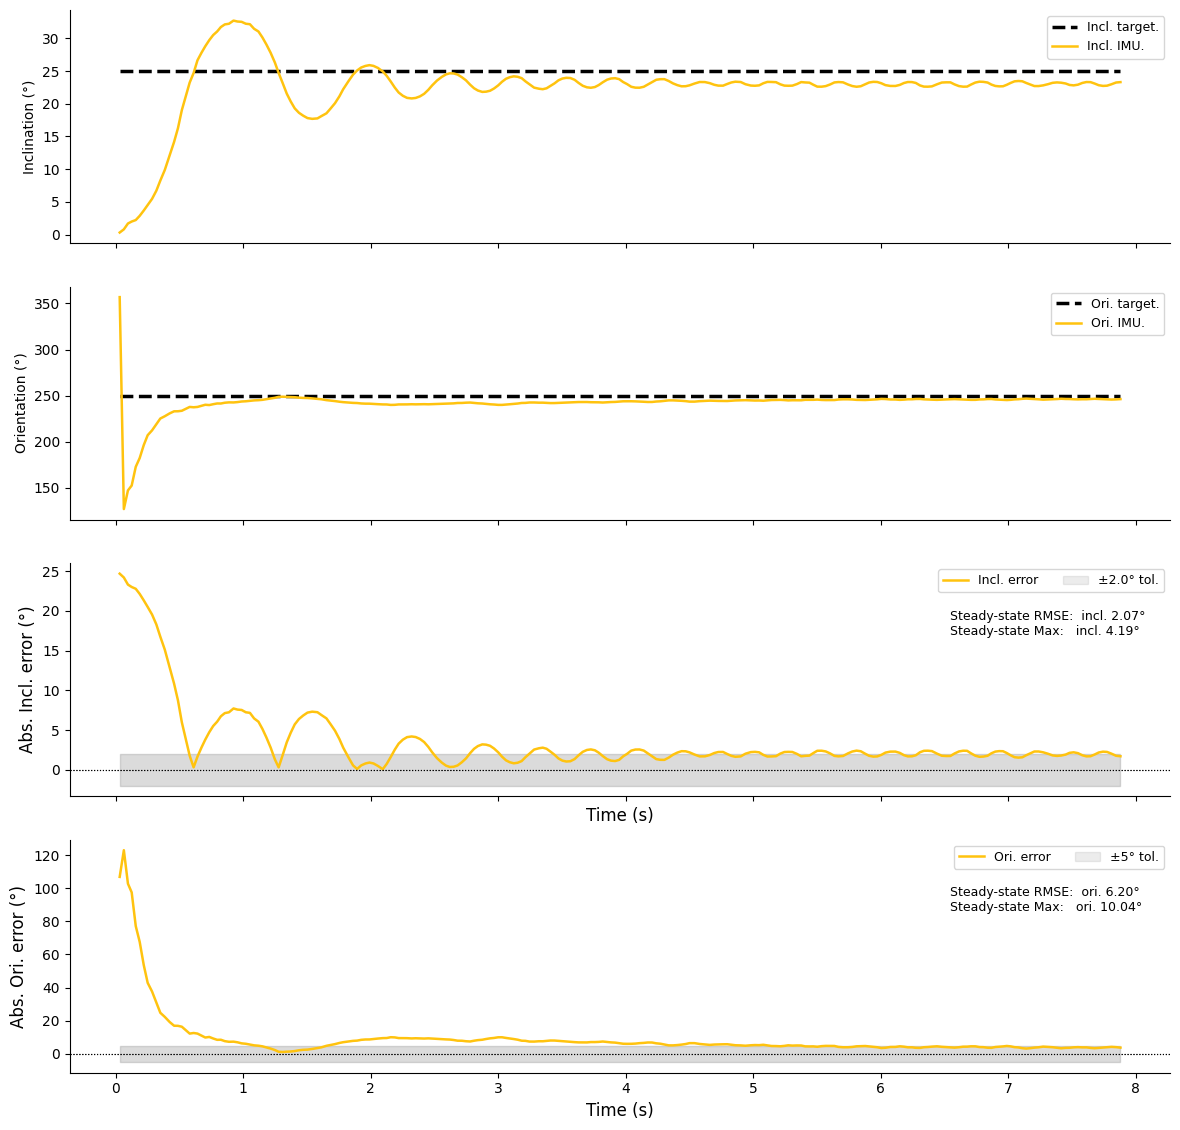

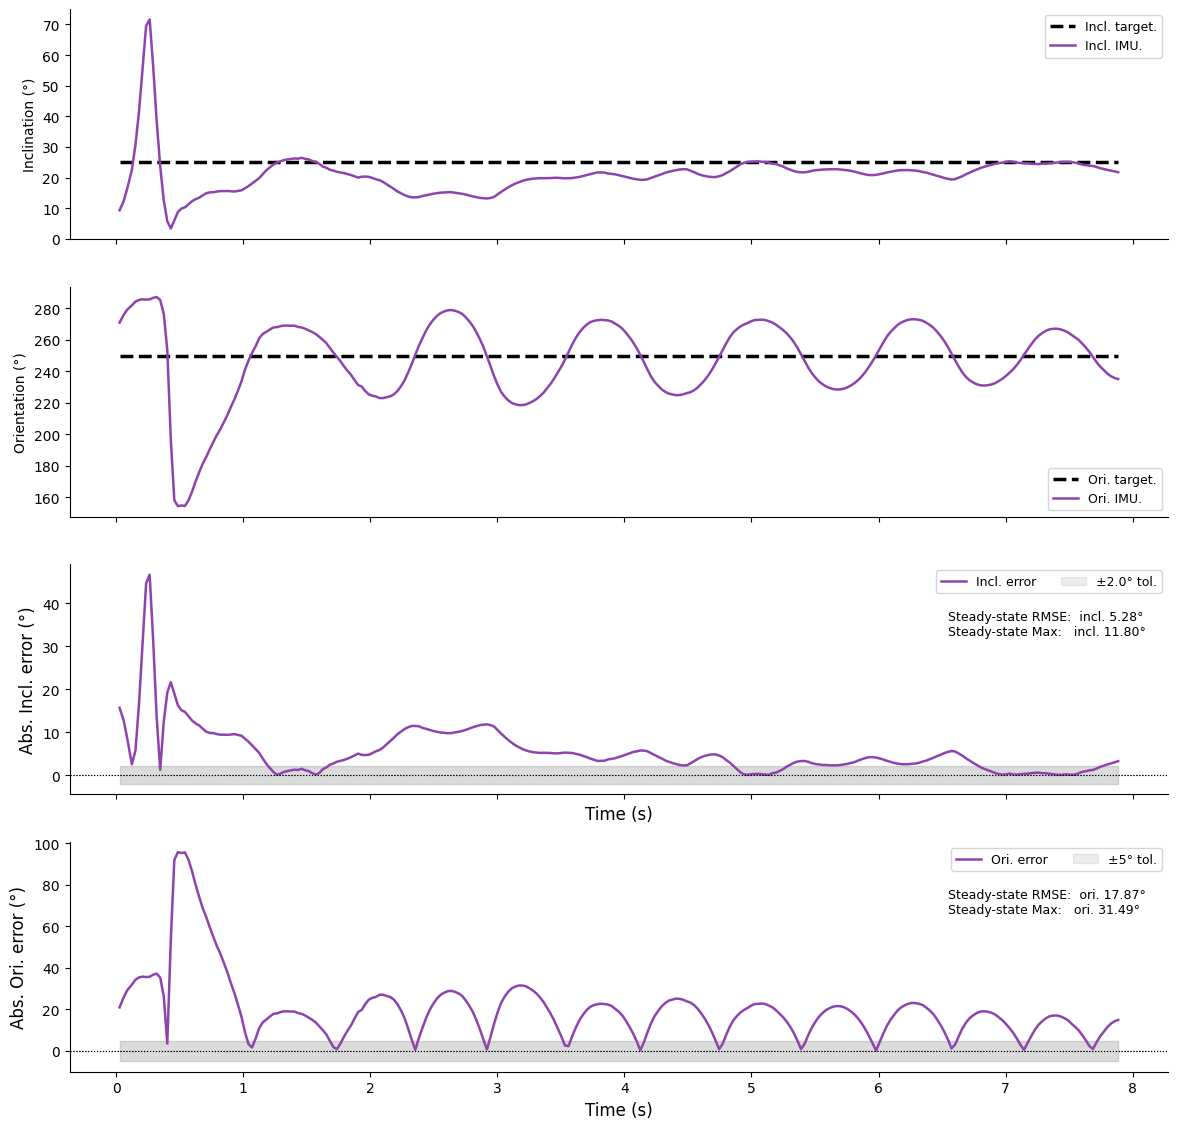

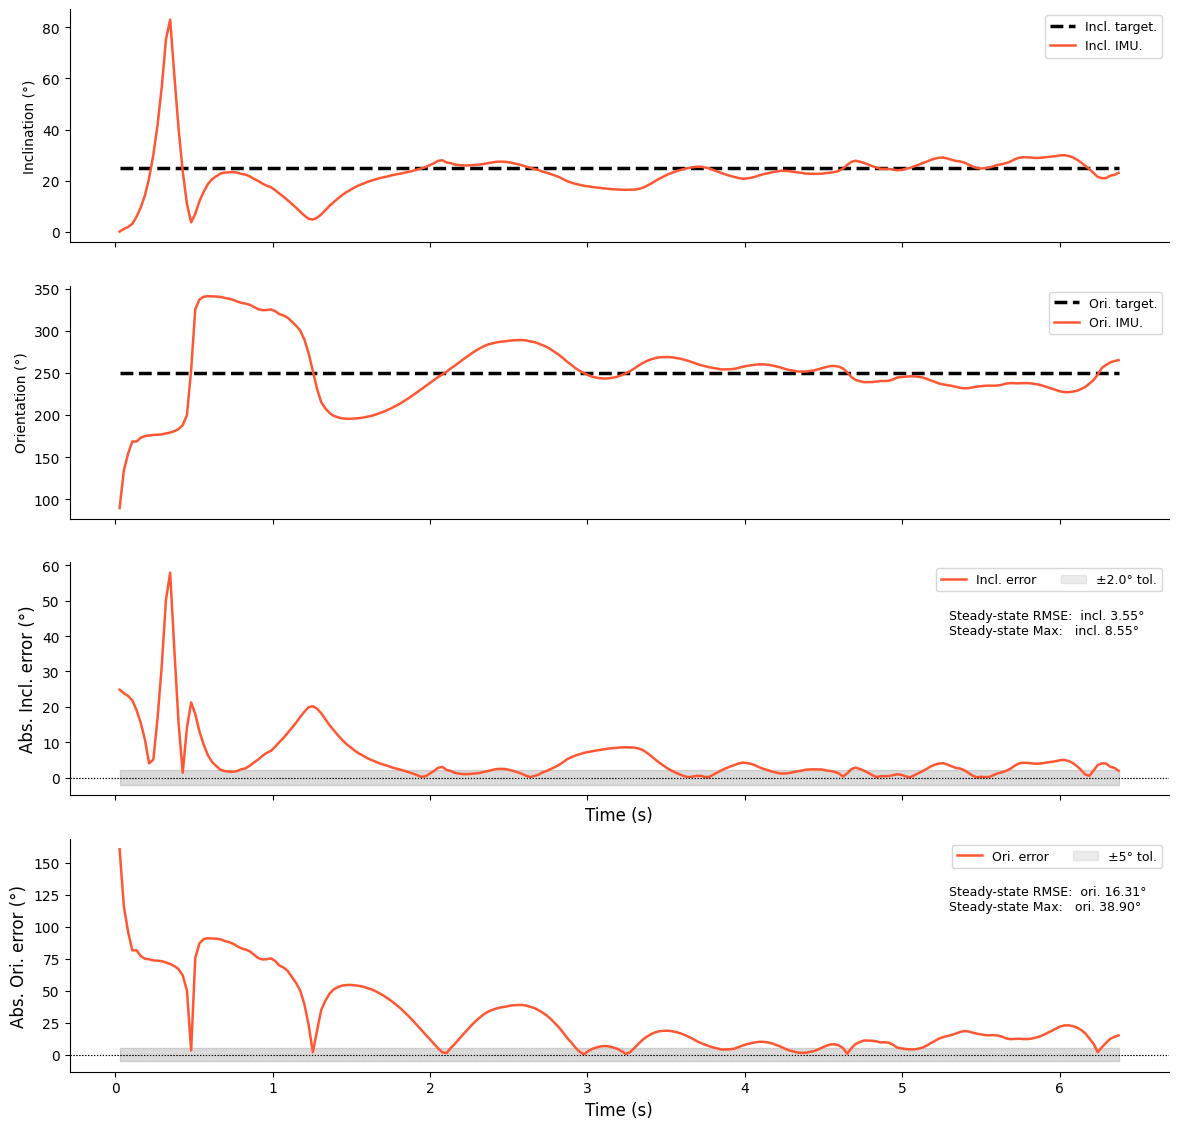

In [6]:
titles = []
err_inc_curves, err_ori_curves = [], []
rmse_inc_list, rmse_ori_list   = [], []
max_inc_list,  max_ori_list    = [], []
time_axis                       = None          # todos usan el mismo t

for time_data, list_incli_target, incli_data, list_orient_target, orient_data, config in trajectories:

    (err_inc, err_ori,
     rmse_inc_ss, rmse_ori_ss,
     max_inc_ss,  max_ori_ss) = plot_pose_and_error(
                                  t=time_data,
                                  inc_ref=list_incli_target,
                                  inc_meas=incli_data,
                                  ori_ref=list_orient_target,
                                  ori_meas=orient_data,
                                  colors=(config['color1'], config['color2']),
                                  tol_deg=2.0)

    # guarda curvas y métricas
    err_inc_curves.append(err_inc)
    err_ori_curves.append(err_ori)
    rmse_inc_list.append(rmse_inc_ss)
    rmse_ori_list.append(rmse_ori_ss)
    max_inc_list.append(max_inc_ss)
    max_ori_list.append(max_ori_ss)

    if time_axis is None:
        time_axis = time_data          # mismo eje de tiempo para todos


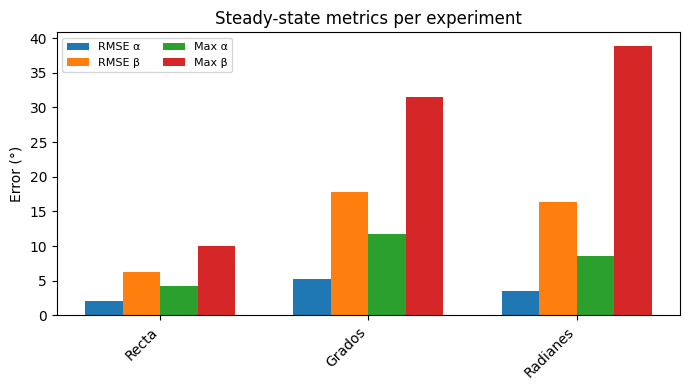

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# FUNCIÓN: barras agrupadas de RMSE y error máximo
# ------------------------------------------------------------
def barplot_metrics(titles,
                    rmse_inc, rmse_ori,
                    max_inc,  max_ori,
                    savefile="fig_metrics.pdf"):
    """
    Dibuja un bar-plot con cuatro métricas steady-state por experimento.
      • RMSE de inclinación   (α)
      • RMSE de orientación   (β)
      • Error máx. inclinación
      • Error máx. orientación
    """
    x     = np.arange(len(titles))      # posiciones de los grupos
    width = 0.18                        # ancho de cada barra

    fig, ax = plt.subplots(figsize=(7, 4))

    # cuatro series desplazadas
    ax.bar(x - 1.5*width, rmse_inc, width, label="RMSE α")
    ax.bar(x - 0.5*width, rmse_ori, width, label="RMSE β")
    ax.bar(x + 0.5*width, max_inc,  width, label="Max α")
    ax.bar(x + 1.5*width, max_ori,  width, label="Max β")

    ax.set_xticks(x)
    ax.set_xticklabels(titles, rotation=45, ha="right")
    ax.set_ylabel("Error (°)")
    ax.set_title("Steady-state metrics per experiment")
    ax.legend(ncol=2, fontsize=8)
    fig.tight_layout()

    if savefile:
        fig.savefig(savefile, bbox_inches="tight")
    plt.show()


# ------------------------------------------------------------
# EJEMPLO DE USO
# ------------------------------------------------------------

titles = ["Recta", "Grados", "Radianes"]


# Generar la figura
barplot_metrics(titles,
                rmse_inc_list, rmse_ori_list,
                max_inc_list,  max_ori_list,
                savefile=False)   # o savefile=False si no quieres guardar


In [8]:
time_arrays = time_axis * 3

In [9]:
print("time_axis:", len(time_axis))
print("err_inc_curves:", [len(e) for e in err_inc_curves])
print("err_ori_curves:", [len(e) for e in err_ori_curves])
print("titles:", len(titles))



time_axis: 240
err_inc_curves: [240, 280, 240]
err_ori_curves: [240, 280, 240]
titles: 3


In [10]:
err_inc_curves[1][:240].size

240

In [11]:
config['color2']

'#FF5733'

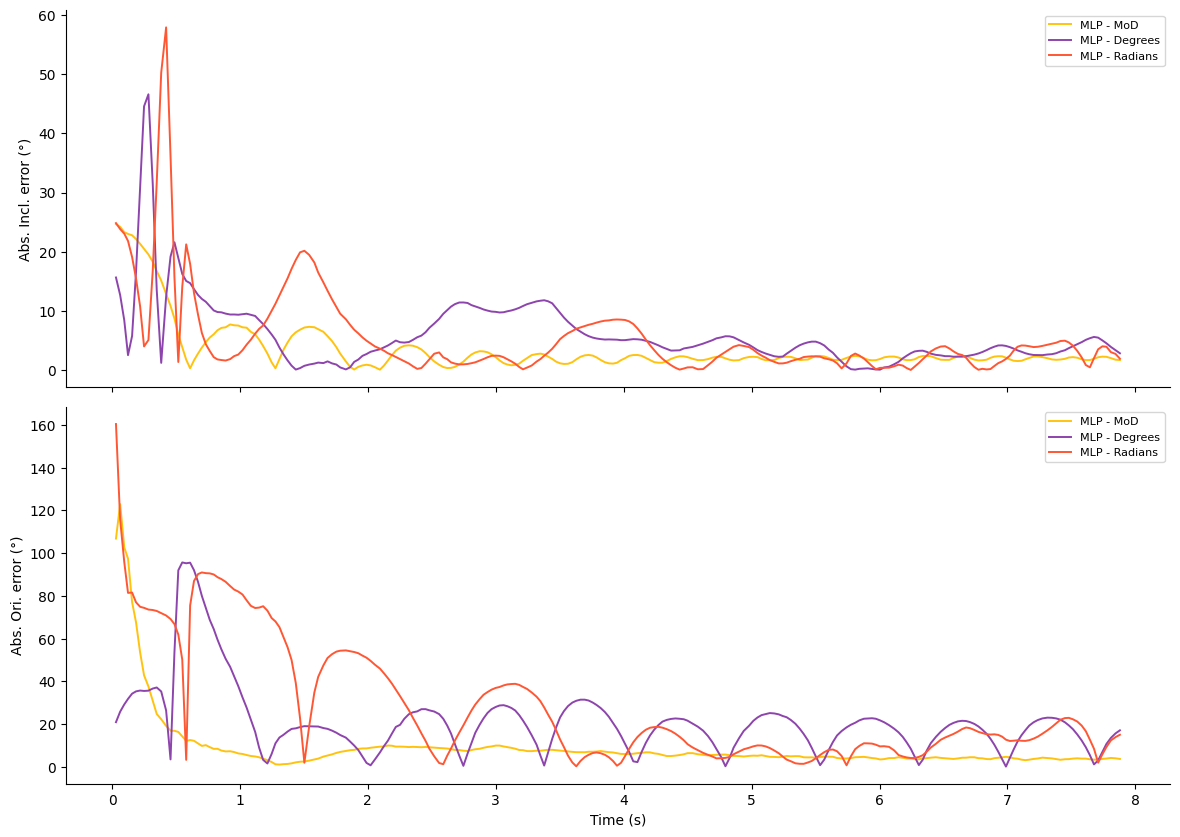

In [12]:
# ─────────────────────────────────────────────────────────────
# DESPUÉS de llenar las listas en el bucle principal
# ─────────────────────────────────────────────────────────────
# 1) Recortar todas las curvas al número mínimo de muestras
  # eje X definitivo (240)
titles = ["MLP - MoD", "MLP - Degrees", "MLP - Radians"]
colors = ["#FFC30F", "#8E44AD","#FF5733"]
desired_len = 240          # longitud que quieres conservar

            # eje X de 0-a-139

inc_trimmed = err_inc_curves[:desired_len]
ori_trimmed = err_ori_curves[:desired_len]
# 2) Dibujar los tres errores de inclinación y orientación
import matplotlib.pyplot as plt

fig, (ax_inc, ax_ori) = plt.subplots(2, 1, figsize=(7, 5), sharex=True)
#fig.suptitle("Absolute errors – 3 experiments", fontsize=13)

# Panel superior: |error inclinación|
for e_curve, lbl, color in zip(inc_trimmed, titles, colors):
    ax_inc.plot(time_axis, e_curve[:240], lw=1.4, label=lbl, color = color)
ax_inc.set_ylabel("Abs. Incl. error (°)")
ax_inc.legend(fontsize=8, frameon=True)
ax_inc.spines[['top', 'right']].set_visible(False)

# Panel inferior: |error orientación|
for e_curve, lbl, color in zip(ori_trimmed, titles, colors):
    ax_ori.plot(time_axis, e_curve[:240], lw=1.4, label=lbl, color = color)
ax_ori.set_ylabel("Abs. Ori. error (°)")
ax_ori.set_xlabel("Time (s)")
ax_ori.legend(fontsize=8, frameon=True)
ax_ori.spines[['top', 'right']].set_visible(False)

fig.tight_layout(rect=[0, 0, 1.7, 1.7])
#plt.savefig("fig_abs_error_compare.pdf", bbox_inches="tight")  # opcional
plt.show()


In [13]:
'''for e_inc, e_ori in zip(err_inc_curves, err_ori_curves):
    'mean_error': np.mean(np.abs(e_inc)),
    'max_error': np.max(np.abs(e_inc)),
    'min_error': np.min(np.abs(e_inc)),
    'rmse': np.sqrt(np.mean(e_inc**2)),
}'''

# ------------------------------------------------------------------
# 2. MÉTRICAS POR EJE
# ------------------------------------------------------------------
mean_inc_list = [np.mean(e) for e in err_inc_curves]
mean_ori_list = [np.mean(e) for e in err_ori_curves]
rmse_pose_list  = []
mean_pose_list  = []
max_pose_list   = []

for e_inc, e_ori in zip(err_inc_curves, err_ori_curves):
    e_pose = np.sqrt(e_inc**2 + e_ori**2)
    rmse_pose_list.append( np.sqrt(np.mean(e_pose**2)) )
    mean_pose_list.append( np.mean(e_pose))
    max_pose_list.append(np.max(e_pose))

# ------------------------------------------------------------------
# 4. CREAR TABLA
# ------------------------------------------------------------------
df_metrics = pd.DataFrame({
    "Experiment One Position"     : titles,
    "RMSE_α (°)"     : rmse_inc_list,
    "MaxErr_α (°)"   : max_inc_list,
    "MeanErr_α (°)"  : mean_inc_list,
    "RMSE_β (°)"     : rmse_ori_list,
    "MaxErr_β (°)"   : max_ori_list,
    "MeanErr_β (°)"  : mean_ori_list,
    "RMSE_pose (°)"  : rmse_pose_list,
    "MeanErr_pose (°)": mean_pose_list
})

# ------------------------------------------------------------------
# 5. MOSTRAR Y GUARDAR
# ------------------------------------------------------------------
df_metrics.round(2)    # redondeo a 2 decimales 



,Experiment One Position,RMSE_α (°),MaxErr_α (°),MeanErr_α (°),RMSE_β (°),MaxErr_β (°),MeanErr_β (°),RMSE_pose (°),MeanErr_pose (°)
0,MLP - MoD,2.07,4.19,3.51,6.20,10.04,9.14,18.65,10.03
1,MLP - Degrees,5.28,11.80,5.35,17.87,31.49,19.86,26.64,21.23
2,MLP - Radians,3.55,8.55,5.36,16.31,38.90,28.27,40.79,29.49


In [14]:
df_metrics["RMSE_pose (°)"]  = rmse_pose_list
df_metrics["Mean_pose (°)"]  = mean_pose_list


# 3. Metrics and Errors SS (Inclination y Orientation)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



Métricas de Inclinación (incluyendo estado estacionario):
                              Una posición RMSE General (grados) RMSE General (%) RMSE Estado Estable (grados) RMSE Estado Estable (%) Error Max General (grados) Error Max Estado Estable (grados) Error Medio General (%) Error Medio Estado Estable (%)
  Control - MLP datos ajustados a la recta                5.670°            22.7%                       2.107°                    8.4%                    24.691°                            4.186°                   14.0%                           7.8%
Control - MLP datos sin procesar en grados                7.847°            27.9%                       6.476°                   25.9%                    46.614°                           11.802°                   20.6%                          22.3%
    Control - MLP datos ajustados radianes                9.067°            30.6%                       4.239°                   17.0%                    57.926°                           

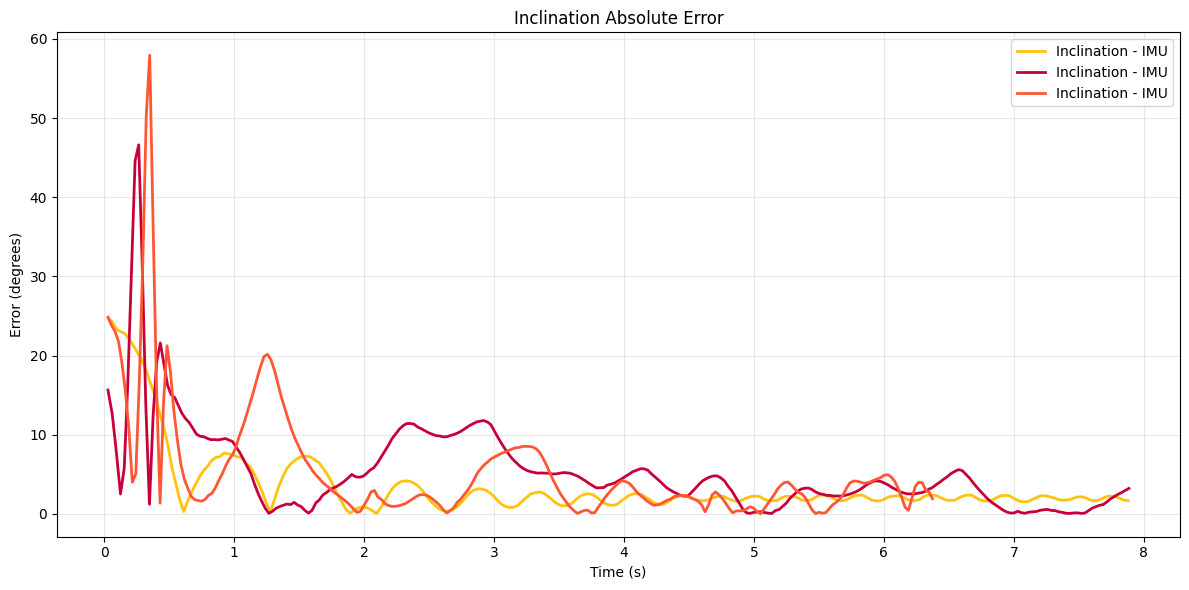

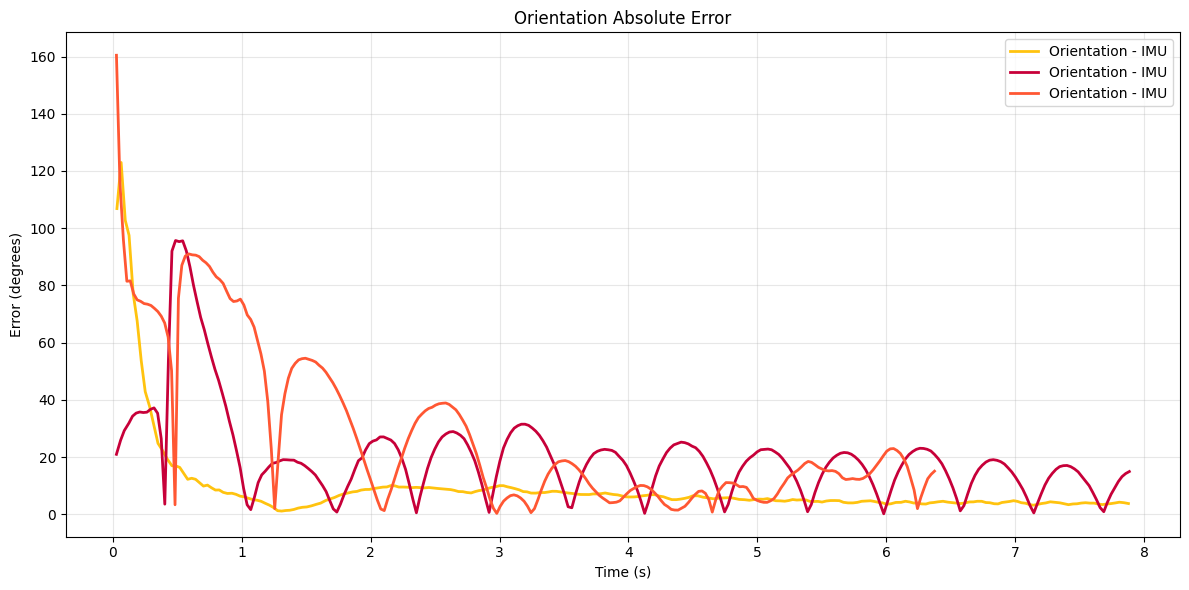

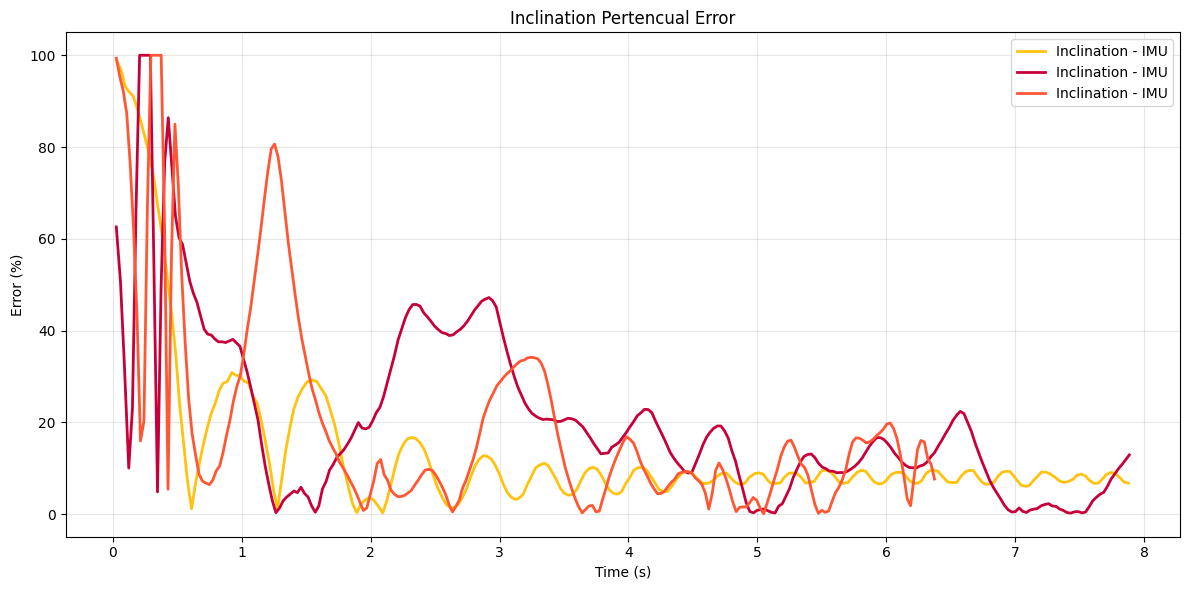

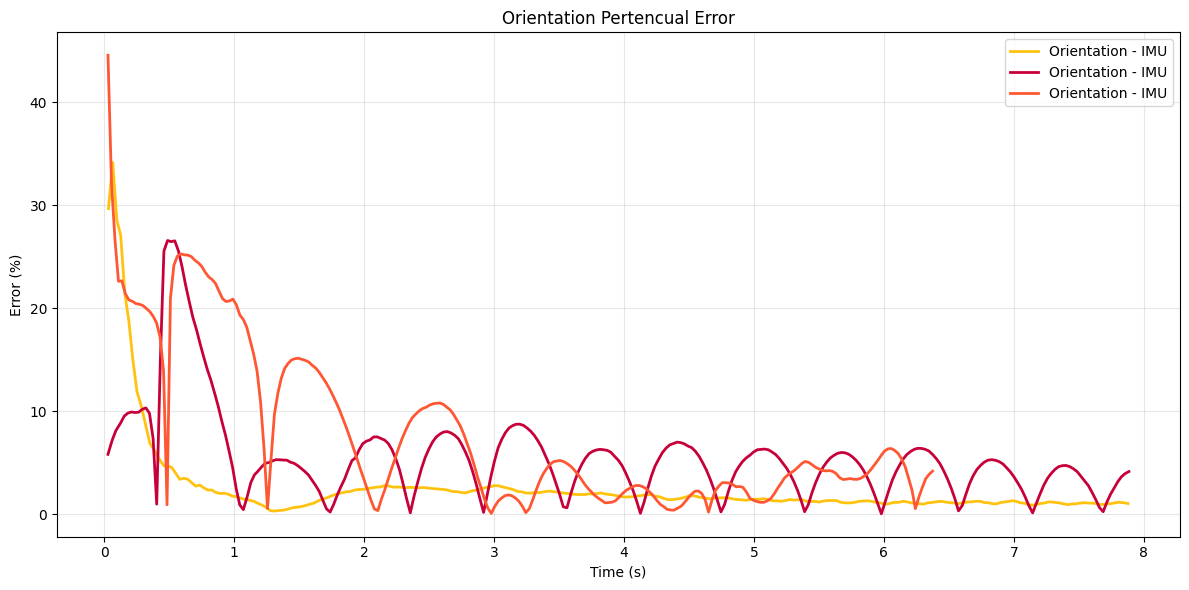

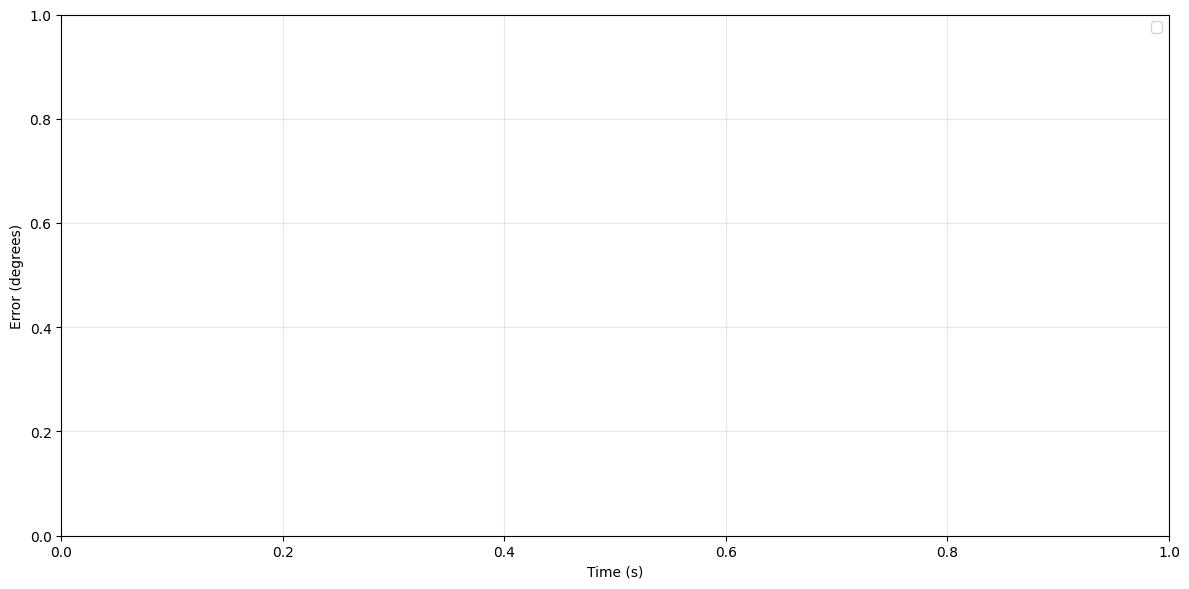

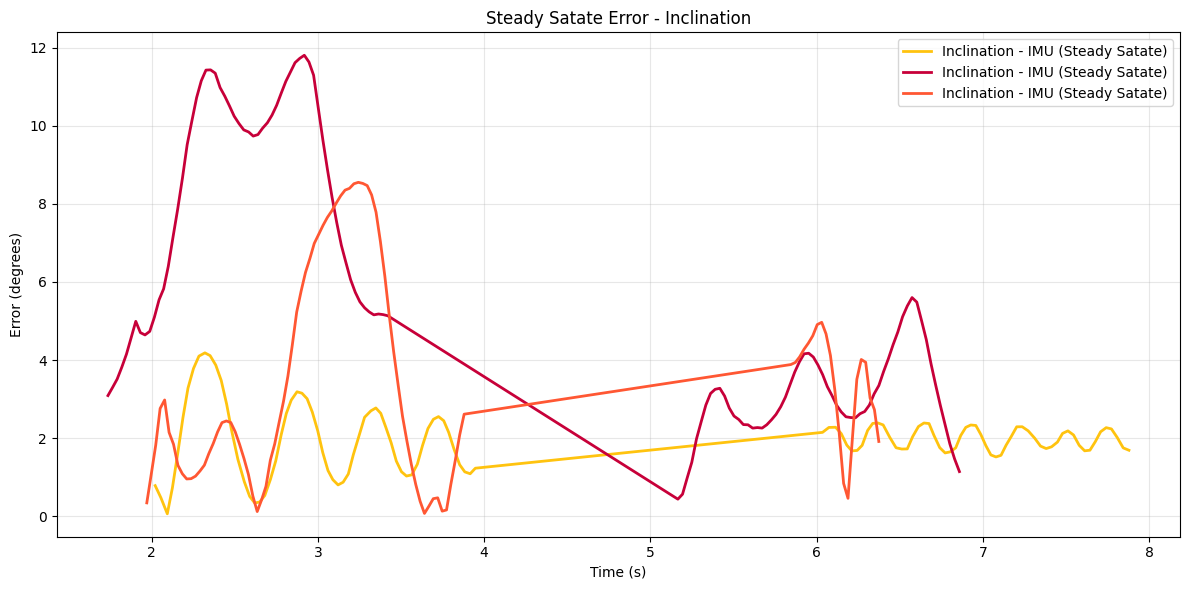

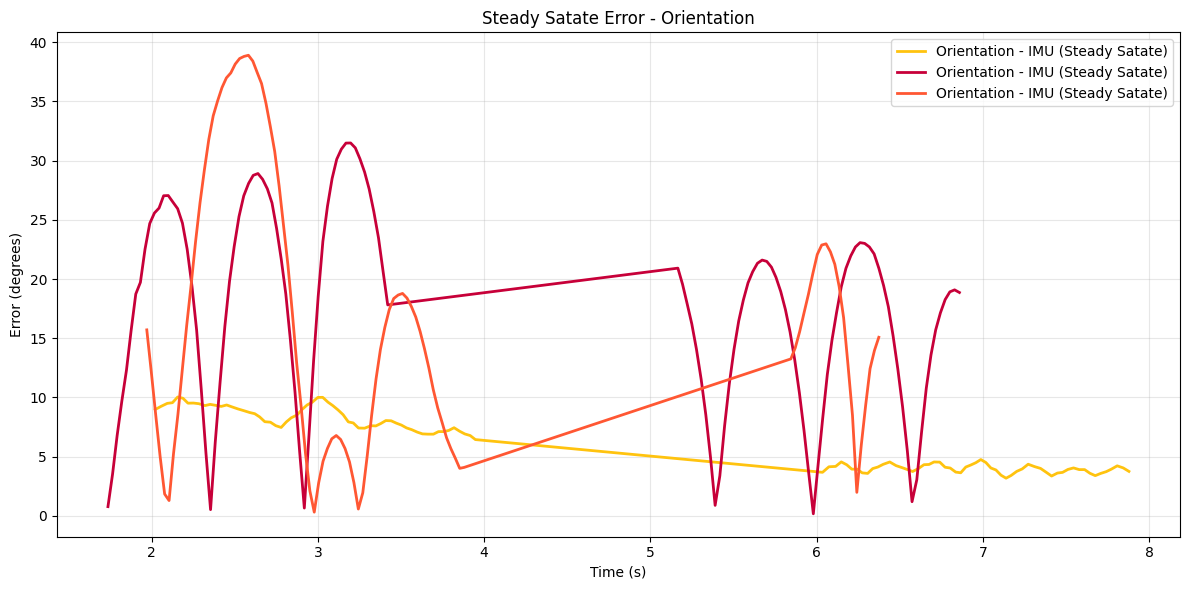

In [15]:
def calculate_angular_error(target, real):
    """
    Calcula el error angular teniendo en cuenta la equivalencia entre 0° y 360°
    """
    import numpy as np
    
    target = np.array(target)
    real = np.array(real)
    direct_diff = np.abs(target - real)
    wrapped_diff = 360 - direct_diff
    return np.minimum(direct_diff, wrapped_diff)

def filter_orientation_jumps(time_data, target_values, real_values, threshold_time=0.1, angle_threshold=300):
    """
    Filtra los puntos donde hay saltos entre 0° y valores cercanos a 360°
    """
    import numpy as np
    
    valid_mask = np.ones(len(time_data), dtype=bool)
    
    for i in range(len(time_data)-1):
        time_diff = time_data[i+1] - time_data[i]
        
        if time_diff <= threshold_time:
            angles = [target_values[i], target_values[i+1], real_values[i], real_values[i+1]]
            has_low = any(angle < 10 for angle in angles)
            has_high = any(angle > angle_threshold for angle in angles)
            
            if has_low and has_high:
                valid_mask[i] = False
                valid_mask[i+1] = False
    
    return (time_data[valid_mask], target_values[valid_mask], 
            real_values[valid_mask], valid_mask)

def calculate_complete_metrics(target_values, real_values, time_data, is_orientation=False):
    """
    Calcula métricas para inclinación, orientación y el sistema completo,
    incluyendo análisis de estado estacionario
    """
    
    valid_mask = None
    if is_orientation:
        # Filtrar puntos problemáticos y calcular error angular para orientación
        time_filtered, target_filtered, real_filtered, valid_mask = filter_orientation_jumps(
            time_data, target_values, real_values
        )
        error = calculate_angular_error(target_filtered, real_filtered)
        time_for_calc = time_filtered
        target_for_calc = target_filtered
    else:
        # Para inclinación, usar cálculo normal
        error = np.abs(np.array(target_values) - np.array(real_values))
        time_for_calc = time_data
        target_for_calc = target_values
    
    # Error porcentual
    epsilon = 1e-5
    if is_orientation:
        percent_error = (error / 360.0) * 100
    else:
        percent_error = (error / np.maximum(np.abs(target_for_calc), epsilon)) * 100
    percent_error = np.minimum(percent_error, 100)
    
    # Calcular estado estacionario
    dt = time_for_calc[1] - time_for_calc[0]
    samples_stabilization = int(2.0 / dt)
    
    steady_state_errors = []
    steady_state_percent_errors = []
    steady_state_times = []
    
    i = samples_stabilization
    while i < len(error):
        steady_state_errors.extend(error[i:i+samples_stabilization])
        steady_state_percent_errors.extend(percent_error[i:i+samples_stabilization])
        steady_state_times.extend(time_for_calc[i:i+samples_stabilization])
        i += 2 * samples_stabilization
    
    steady_state_errors = np.array(steady_state_errors)
    steady_state_percent_errors = np.array(steady_state_percent_errors)
    
    metrics = {
        'general': {
            'rmse_grados': np.sqrt(np.mean(error**2)),
            'rmse_porcentaje': np.sqrt(np.mean(percent_error**2)),
            'error_max_grados': np.max(error),
            'error_medio_grados': np.mean(error),
            'error_medio_porcentaje': np.mean(percent_error)
        },
        'estado_estable': {
            'rmse_grados': np.sqrt(np.mean(steady_state_errors**2)),
            'rmse_porcentaje': np.sqrt(np.mean(steady_state_percent_errors**2)),
            'error_max_grados': np.max(steady_state_errors),
            'error_medio_grados': np.mean(steady_state_errors),
            'error_medio_porcentaje': np.mean(steady_state_percent_errors)
        }
    }
    
    return metrics, error, percent_error, steady_state_errors, steady_state_times, valid_mask


def analyze_trajectories_complete(csv_paths, plot_configs):
    """
    Análisis completo de todas las trayectorias con gráficas separadas
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    
    all_metrics = []
    
    # Crear figuras separadas
    figs = {
        'error_incli': plt.figure(figsize=(12, 6)),
        'error_orient': plt.figure(figsize=(12, 6)),
        'error_incli_percent': plt.figure(figsize=(12, 6)),
        'error_orient_percent': plt.figure(figsize=(12, 6)),
        'error_system': plt.figure(figsize=(12, 6)),
        'steady_state_incli': plt.figure(figsize=(12, 6)),
        'steady_state_orient': plt.figure(figsize=(12, 6))
    }
    
    axes = {name: fig.add_subplot(111) for name, fig in figs.items()}
    
    for path, config in zip(csv_paths, plot_configs):
        data = pd.read_csv(path)
        time_data = data['Time'].values
        
        # Calcular métricas para inclinación
        incli_metrics, incli_error, incli_percent, incli_steady, incli_steady_times, valid_mask = \
            calculate_complete_metrics(
                data['Target Incli'].values,
                data['Real Incli'].values,
                time_data,
                is_orientation=False
            )
        
        # Calcular métricas para orientación y obtener la máscara de datos válidos
        orient_metrics, orient_error, orient_percent, orient_steady, orient_steady_times, valid_mask = \
            calculate_complete_metrics(
                data['Target Orient'].values,
                data['Real Orient'].values,
                time_data,
                is_orientation=True
            )
        
        # Usar la misma máscara para el tiempo en las gráficas de orientación
        time_filtered = time_data[valid_mask] if valid_mask is not None else time_data
        
        # Almacenar métricas
        all_metrics.append({
            'name': config['title'],
            'inclinacion': incli_metrics,
            'orientacion': orient_metrics
        })
        
        # Plotear errores regulares
        axes['error_incli'].plot(time_data, incli_error, color=config['color2'],
                               label=f"{config['legend2']}", linewidth=2)
        axes['error_orient'].plot(time_filtered, orient_error, color=config['color2'],
                                label=f"{config['legend3']}", linewidth=2)
        
        # Plotear errores porcentuales
        axes['error_incli_percent'].plot(time_data, incli_percent, color=config['color2'],
                                       label=f"{config['legend2']}", linewidth=2)
        axes['error_orient_percent'].plot(time_filtered, orient_percent, color=config['color2'],
                                        label=f"{config['legend3']}", linewidth=2)
        
        # Plotear errores en estado estacionario
        axes['steady_state_incli'].plot(incli_steady_times, incli_steady, color=config['color2'],
                                      label=f"{config['legend2']} (Steady Satate)", linewidth=2)
        axes['steady_state_orient'].plot(orient_steady_times, orient_steady, color=config['color2'],
                                       label=f"{config['legend3']} (Steady Satate)", linewidth=2)
    
    # El resto del código sigue igual...
    # Configurar todas las gráficas
    titles = {
        'error_incli': 'Inclination Absolute Error',
        'error_orient': 'Orientation Absolute Error',
        'error_incli_percent': 'Inclination Pertencual Error',
        'error_orient_percent': 'Orientation Pertencual Error',
        'steady_state_incli': 'Steady Satate Error - Inclination',
        'steady_state_orient': 'Steady Satate Error - Orientation'
    }
    
    for name, ax in axes.items():
        ax.set_title(titles.get(name, ''))
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Error' + (' (%)' if 'percent' in name else ' (degrees)'))
        ax.grid(True, alpha=0.3)
        ax.legend()
        figs[name].tight_layout()
    
    # Crear tablas comparativas incluyendo estado estacionario
    comparison_tables = {
        'Inclinación': pd.DataFrame([{
            'Una posición': m['name'],
            'RMSE General (grados)': f"{m['inclinacion']['general']['rmse_grados']:.3f}°",
            'RMSE General (%)': f"{m['inclinacion']['general']['rmse_porcentaje']:.1f}%",
            'RMSE Estado Estable (grados)': f"{m['inclinacion']['estado_estable']['rmse_grados']:.3f}°",
            'RMSE Estado Estable (%)': f"{m['inclinacion']['estado_estable']['rmse_porcentaje']:.1f}%",
            'Error Max General (grados)': f"{m['inclinacion']['general']['error_max_grados']:.3f}°",
            'Error Max Estado Estable (grados)': f"{m['inclinacion']['estado_estable']['error_max_grados']:.3f}°",
            'Error Medio General (%)': f"{m['inclinacion']['general']['error_medio_porcentaje']:.1f}%",
            'Error Medio Estado Estable (%)': f"{m['inclinacion']['estado_estable']['error_medio_porcentaje']:.1f}%"
        } for m in all_metrics]),
        
        'Orientación': pd.DataFrame([{
            'Una posición': m['name'],
            'RMSE General (grados)': f"{m['orientacion']['general']['rmse_grados']:.3f}°",
            'RMSE General (%)': f"{m['orientacion']['general']['rmse_porcentaje']:.1f}%",
            'RMSE Estado Estable (grados)': f"{m['orientacion']['estado_estable']['rmse_grados']:.3f}°",
            'RMSE Estado Estable (%)': f"{m['orientacion']['estado_estable']['rmse_porcentaje']:.1f}%",
            'Error Max General (grados)': f"{m['orientacion']['general']['error_max_grados']:.3f}°",
            'Error Max Estado Estable (grados)': f"{m['orientacion']['estado_estable']['error_max_grados']:.3f}°",
            'Error Medio General (%)': f"{m['orientacion']['general']['error_medio_porcentaje']:.1f}%",
            'Error Medio Estado Estable (%)': f"{m['orientacion']['estado_estable']['error_medio_porcentaje']:.1f}%"
        } for m in all_metrics])
    }
    
    return figs, comparison_tables




# Definir las rutas y configuraciones
datasets = [
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_recta.csv',
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_degree_v2.csv',
    '/Users/nicolecontinelli/Desktop/SOFIA_Python/data/Data_2025/Data_Paper_Robotics/one_pos_rad_v6.csv'

]

configs = [
    {
        'title': "Control - MLP datos ajustados a la recta",
        'color1': "black",
        'color2': "#FFC30F",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    },
    {
        'title': "Control - MLP datos sin procesar en grados",
        'color1': "black",
        'color2': "#C70039",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    },
    {
        'title': "Control - MLP datos ajustados radianes",
        'color1': "black",
        'color2': "#FF5733",
        'legend1': "Target",
        'legend2': "Inclination - IMU",
        'legend3': "Orientation - IMU"
    }
]
# Usar con tus configuraciones existentes
figs, tables = analyze_trajectories_complete(datasets, configs)

# Mostrar tablas
print("\nMétricas de Inclinación (incluyendo estado estacionario):")
print(tables['Inclinación'].to_string(index=False))
print("\nMétricas de Orientación (incluyendo estado estacionario):")
print(tables['Orientación'].to_string(index=False))

In [16]:
tables['Inclinación']

,Una posición,RMSE General (grados),RMSE General (%),RMSE Estado Estable (grados),RMSE Estado Estable (%),Error Max General (grados),Error Max Estado Estable (grados),Error Medio General (%),Error Medio Estado Estable (%)
0,Control - MLP datos ajustados a la recta,5.670°,22.7%,2.107°,8.4%,24.691°,4.186°,14.0%,7.8%
1,Control - MLP datos sin procesar en grados,7.847°,27.9%,6.476°,25.9%,46.614°,11.802°,20.6%,22.3%
2,Control - MLP datos ajustados radianes,9.067°,30.6%,4.239°,17.0%,57.926°,8.550°,20.2%,13.4%


In [17]:
tables['Orientación']

,Una posición,RMSE General (grados),RMSE General (%),RMSE Estado Estable (grados),RMSE Estado Estable (%),Error Max General (grados),Error Max Estado Estable (grados),Error Medio General (%),Error Medio Estado Estable (%)
0,Control - MLP datos ajustados a la recta,17.766°,4.9%,6.651°,1.8%,122.969°,10.037°,2.5%,1.7%
1,Control - MLP datos sin procesar en grados,25.460°,7.1%,19.247°,5.3%,95.688°,31.491°,5.5%,4.8%
2,Control - MLP datos ajustados radianes,39.769°,11.0%,19.763°,5.5%,160.444°,38.900°,7.9%,4.5%
